### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Sophia Lunian Liu
*   Your **student number**: 1006045833



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [2]:
### YOUR CODE HERE ###
#print(raw_data)
#type(countries_list_url)
countries_list = requests.get(countries_list_url).text.splitlines()
#print(countries_list)

data_filtered_countries = raw_data[raw_data["entity"].isin(countries_list)]
#print(data_filtered_countries)

data_filtered = data_filtered_countries[(data_filtered_countries["year"] >= 1901) & (data_filtered_countries["year"] <=2023)]
#print(data_filtered)

data = data_filtered.pivot(index = "entity", columns = "year", values = "population_historical")

data = data.dropna()
print(data)


year               1901        1902        1903        1904        1905  \
entity                                                                    
Afghanistan   4751177.0   4802500.0   4861833.0   4921891.0   4982681.0   
Albania        813539.0    821036.0    828461.0    835954.0    843514.0   
Algeria       4787149.0   4859600.0   4939332.0   5020372.0   5102742.0   
Andorra          4551.0      4581.0      4610.0      4640.0      4670.0   
Angola        3083888.0   3064493.0   3043335.0   3022320.0   3001447.0   
...                 ...         ...         ...         ...         ...   
Venezuela     2733334.0   2765603.0   2796321.0   2827377.0   2858773.0   
Vietnam      12199511.0  12734169.0  13412346.0  14126641.0  14878976.0   
Yemen         2984894.0   3006808.0   3033193.0   3059809.0   3086657.0   
Zambia        1605378.0   1596265.0   1585596.0   1574998.0   1564469.0   
Zimbabwe      1127021.0   1144303.0   1163263.0   1182536.0   1202129.0   

year               1906 

1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [3]:
pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.6 MB/s eta 0:00:00


The closest country is: Serbia with distance of 3
The second closest country is: Somalia with distance of 3


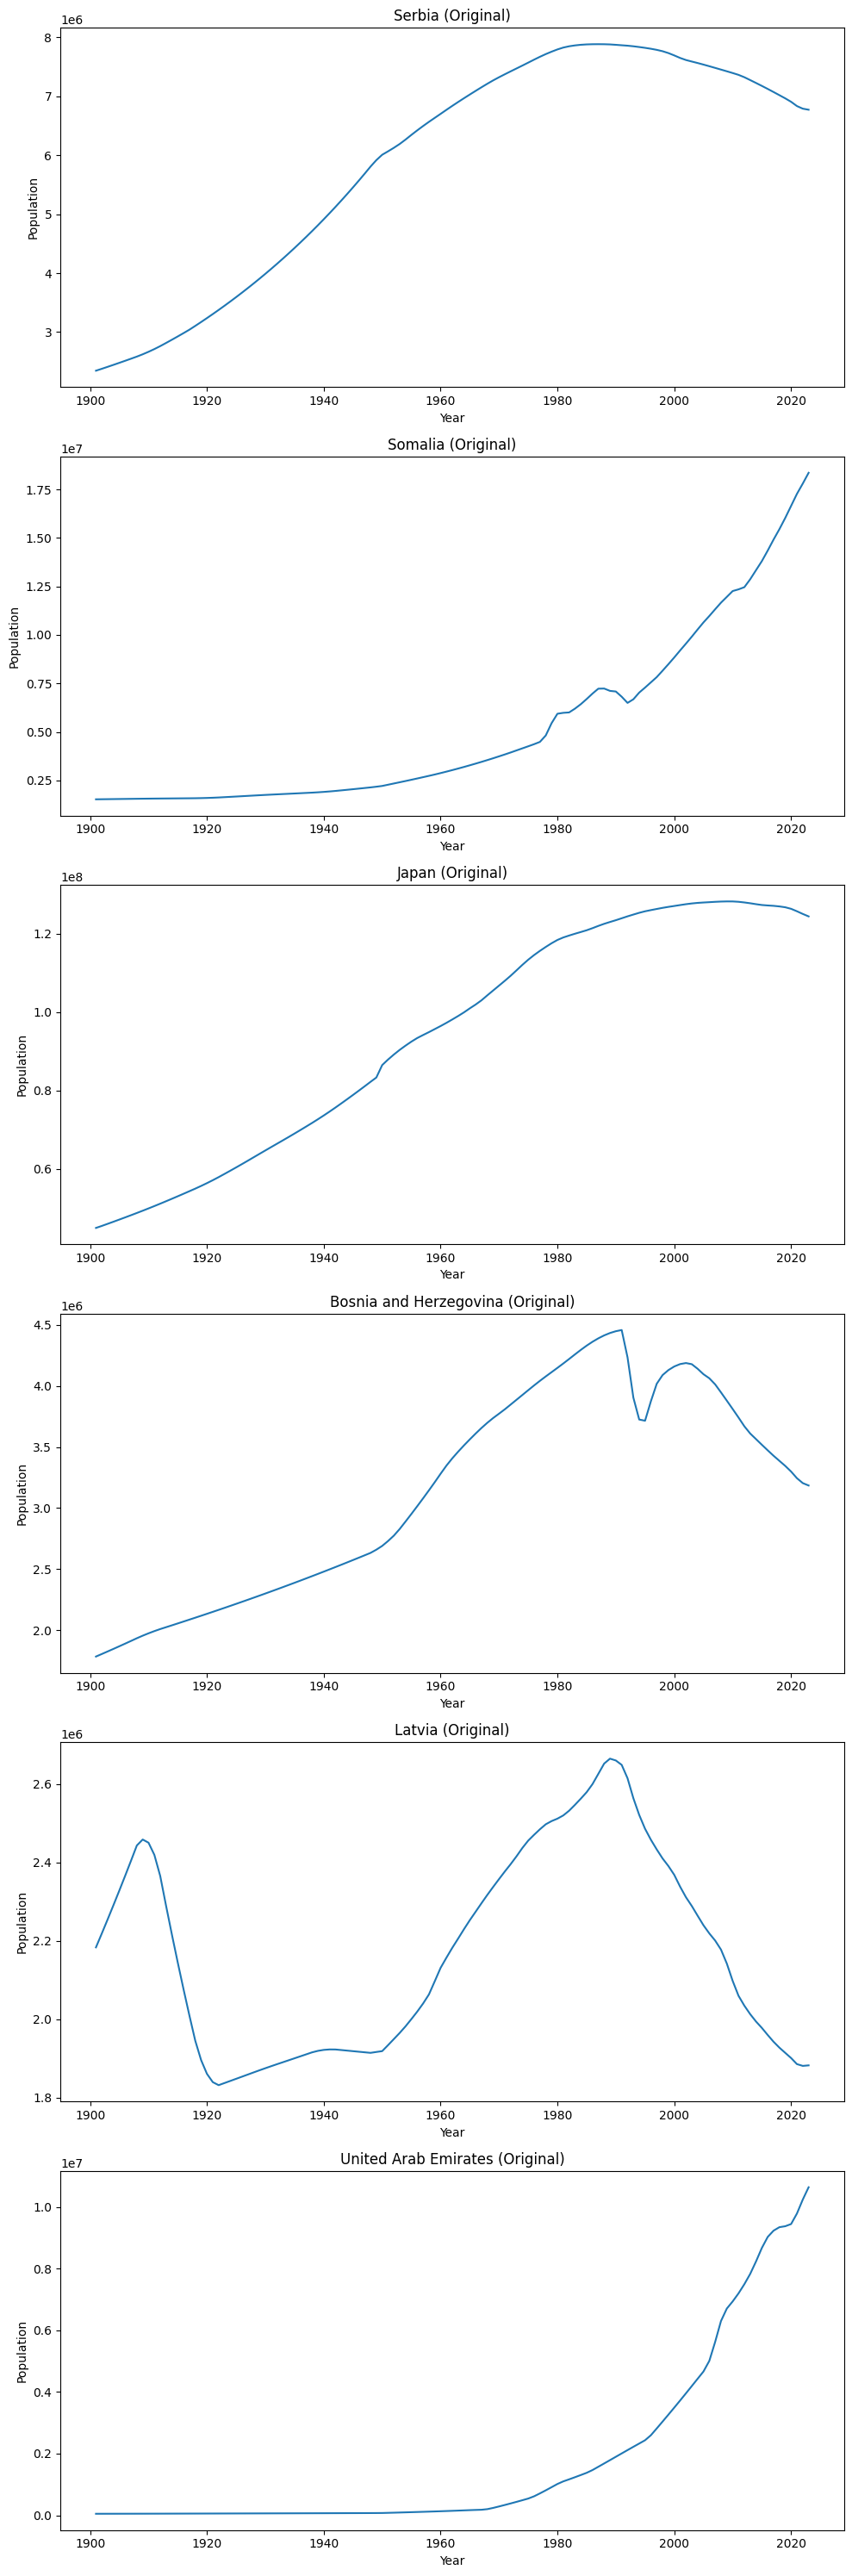

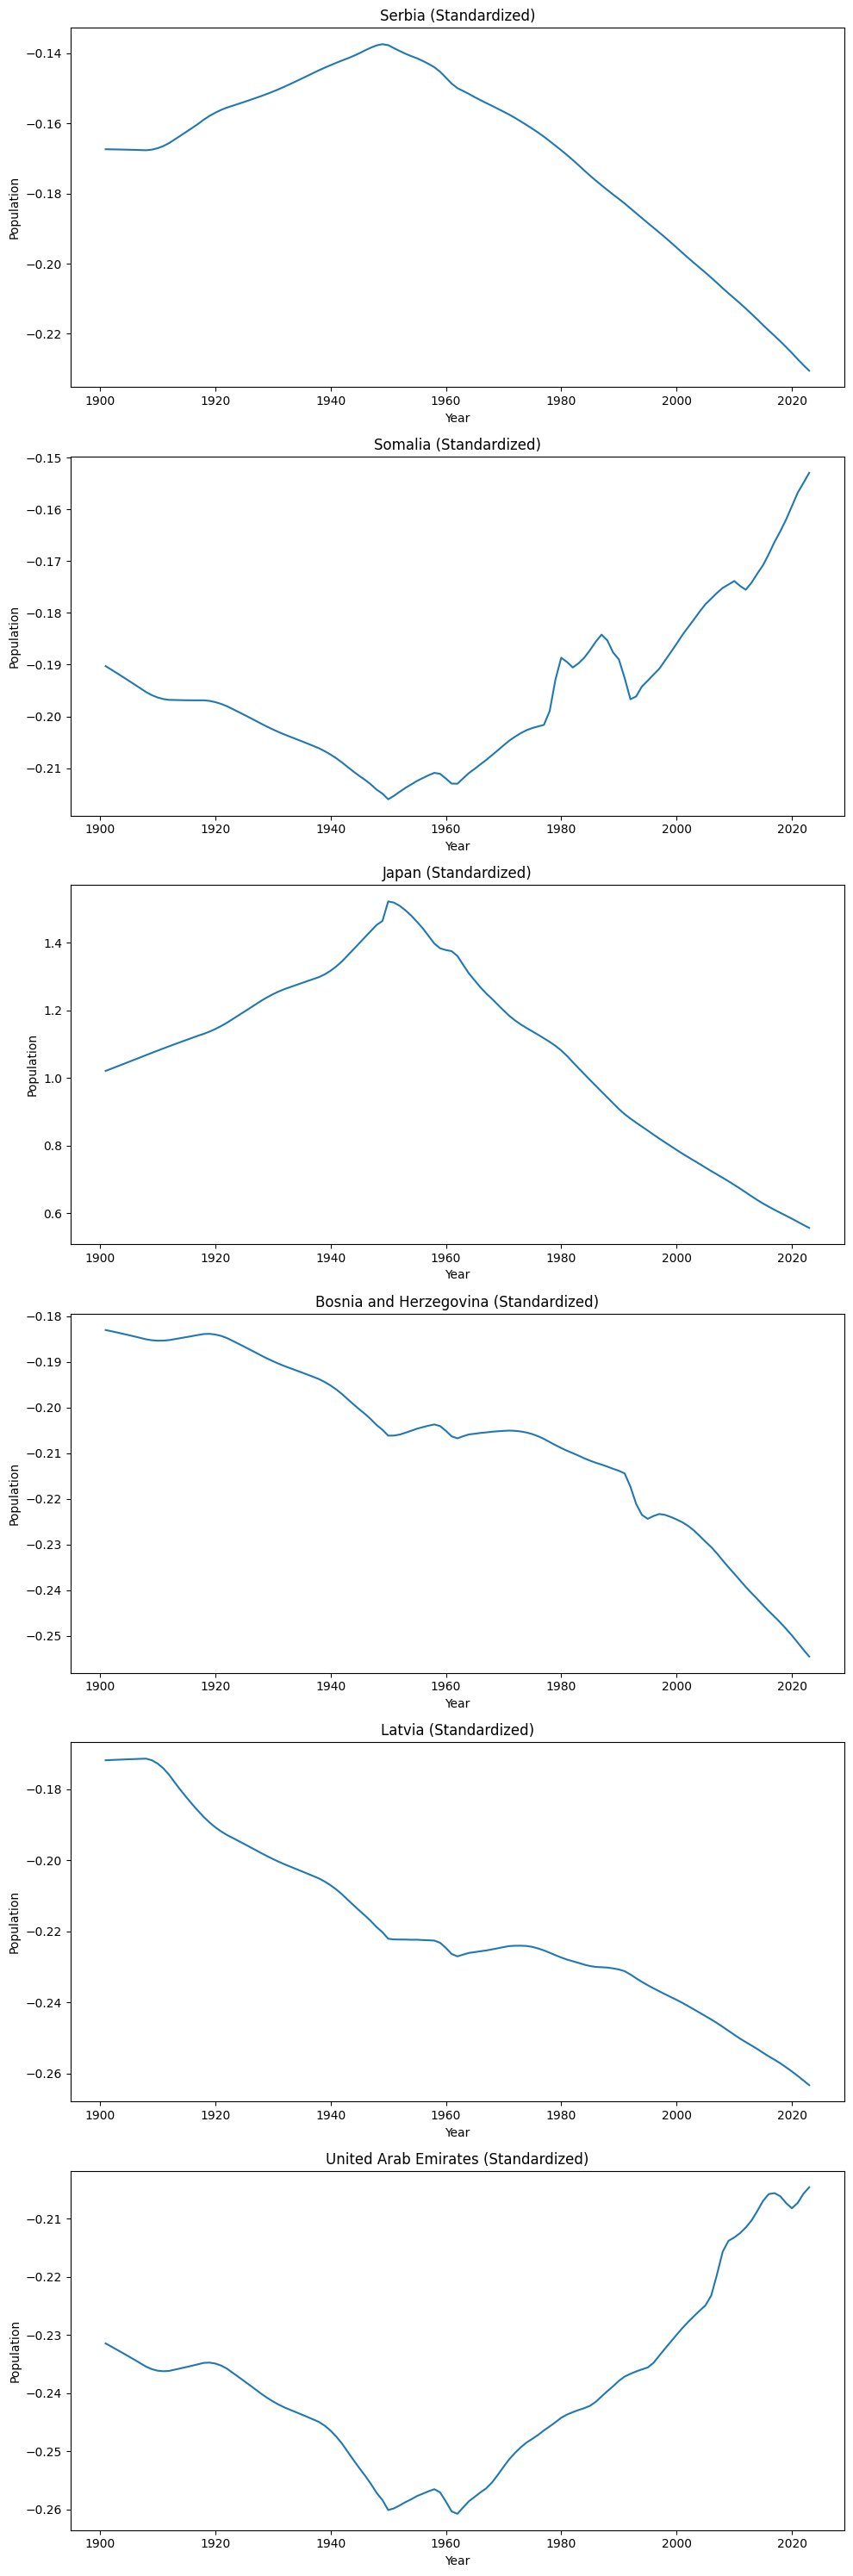

In [4]:
### YOUR CODE HERE ###
#1. graph function
import matplotlib.pyplot as plt

def plot_time_series(data, countries, plot_title):

    plt.figure(figsize=(10, 5*len(countries)))

    for i in range(len(countries)):
      plt.subplot(len(countries), 1, i+1)
      plt.plot(data.columns, data.loc[countries[i]])
      plt.title(countries[i] + " (" + plot_title + ")")
      plt.xlabel("Year")
      plt.ylabel("Population")

    plt.tight_layout()
    plt.show()

#plot_time_series(data, data.index.tolist())

#2. standardize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = pd.DataFrame(scaler.fit_transform(data), index = data.index, columns = data.columns)

#3. pick two countries
first_name = "sophia"

import Levenshtein

closest_country_1 = ""
closest_country_2 = ""

distance_min_1 = float("inf")
distance_min_2 = float("inf")

for country in data.index:

  dist_calc = Levenshtein.distance(first_name, country.lower())

  if dist_calc < distance_min_1:
    distance_min_2 = distance_min_1
    closest_country_2 = closest_country_1

    distance_min_1 = dist_calc
    closest_country_1 = country

  elif dist_calc < distance_min_2:
    distance_min_2 = dist_calc
    closest_country_2 = country

print("The closest country is:", closest_country_1, "with distance of", distance_min_1)
print("The second closest country is:", closest_country_2, "with distance of", distance_min_2)

#4. plot graph
countries_to_plot = [closest_country_1, closest_country_2, "Japan", "Bosnia and Herzegovina", "Latvia", "United Arab Emirates"]

plot_time_series(data, countries_to_plot, "Original")
plot_time_series(data_scaled, countries_to_plot, "Standardized")



The original graphs demonstrate the actual population of each country over time. From the graphs, we can observe the following:

**Serbia**: Population keeps increasing until the 1980s and then gradually decreases.

**Somalia**: Population keeps increasing, and the rate of change increases after 2000.

**Japan**: Population increases until around 2010, reaching a peak, and then starts to decrease.

**Bosnia and Herzegovina**: Population increases first, and then shows a sudden drop in the 1990s. Although it rebounded right after the drop, it still shows a general decreasing trend.

**Latvia**: Population increases between the 1900s and the 1910s then starts to decline until the 1920s. Afterwards, the population gradually increases, reaching a peak in the 1990s, after which it starts to decrease.

**United Arab Emirates**: Population starts to rapidly grow after the 1970s.

After standardization, the populations of all countries are standardized to have a mean of 0 and a standard deviation of 1. Therefore, different countries can be compared on the same scale. The standardized data present the relative position of the population of a certain country compared to the mean population of all the 196 countries filtered from the dataset.

**Serbia**: The curve gradually increases and then keeps decreasing, meaning that the population of Serbia continued to grow during the 1900s, however, the speed of its population growth was slower than the global population growth.

**Somalia**: The curve decreases before the mid-20th century then keeps increasing, especially showing an obvious increasing trend after 2000. This implies that the population growth rate in Somalia is much faster than that of many other countries.

**Japan**: The standardized value is positive between 1901 and 2023, and it reaches a peak in 1950 then keeps decreasing. The population in Japan is always higher than the global average, while other countries show a higher population growth rate, making Japan's relative population advantage gradually weaker.

**Bosnia and Herzegovina**: The standardized curve shows an overall decreasing trend. Although the population continued to increase before the 1990s, its population growth rate is lower than the global average. After the sudden population decline in the 1990s, its relative position declined even further.

**Latvia**: The standardized curve gradually decreases throughout the period, indicating that Latvia's population became relatively smaller compared with other countries over time. The decline became more noticable after the 1990s, which is consistent with the decreasing trend observed in the original data.

**United Arab Emirates**: The standardized curve reaches its lowest point around the 1960s and then increases rapidly afterwards. This indicated that the population growth rate in the United Arab Emirates became much faster than the global average.

An upward curve indicates that a country's population is becoming larger relative to other countries, while a downward curve indicates that its relative position is declining. This does not necessarily mean that the actual population is increasing or decreasing.

Positive standardized values indicate that a country's population is above the average population of all countries in that year, whereas negative values indicate that it is below the yearly average.